# Projeto de Análise de Dados - Sono e Saúde

### Importar Bibliotecas e Dataset

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("sleepHealth.csv")

### Informações das Colunas

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    str    
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    str    
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    str    
 9   Blood Pressure           374 non-null    str    
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 38.1 KB


*   **Person ID:** Identificador único para cada pessoa.
*   **Gender:** Gênero da pessoa (Masculino/Feminino).
*   **Age:** Idade da pessoa em anos.
*   **Occupation:** Profissão da pessoa.
*   **Sleep Duration:** Duração do sono em horas.
*   **Quality of Sleep:** Nota de 1 a 10 que representa a qualidade do sono.
*   **Physical Activity Level:** Nível de atividade física da pessoa em minutos por dia.
*   **Stress Level:** Nível de estresse da pessoa em uma escala de 1 a 10.
*   **BMI Category:** Categoria de Índice de Massa Corporal (IMC) da pessoa (Normal, Sobrepeso, Obeso).
*   **Blood Pressure:** Pressão sanguínea da pessoa (sistólica/diastólica).
*   **Heart Rate:** Frequência cardíaca da pessoa em batimentos por minuto.
*   **Daily Steps:** Número de passos diários da pessoa.
*   **Sleep Disorder:** Distúrbio do sono diagnosticado (Insônia, Apneia do Sono, ou NaN se nenhum distúrbio).

```
# Coluna alvo : Quality of Sleep
```



### Tratamento

In [ ]:
df = df.fillna('None')
# Nesse caso, o principal e único tratamento que foi necessário por esse dataset foi para a coluna 'Sleep Disorder', única que continha valores nulos e, por isso, preencher
# com 'None' para facilitar a análise posteriormente
df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


### Obtendo Informações Gerais dos Dados

Aqui a função describe para ver algumas informações relevantes de cada coluna

In [ ]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


Podemos ter uma ideia da distribuição de nossa variável alvo "Qualidade de sono", utilizando as bibliotecas seaborn e matplotlib para criar um histograma e um boxplot.

In [8]:
sns.set(style="whitegrid")

Text(0, 0.5, 'Frequência')

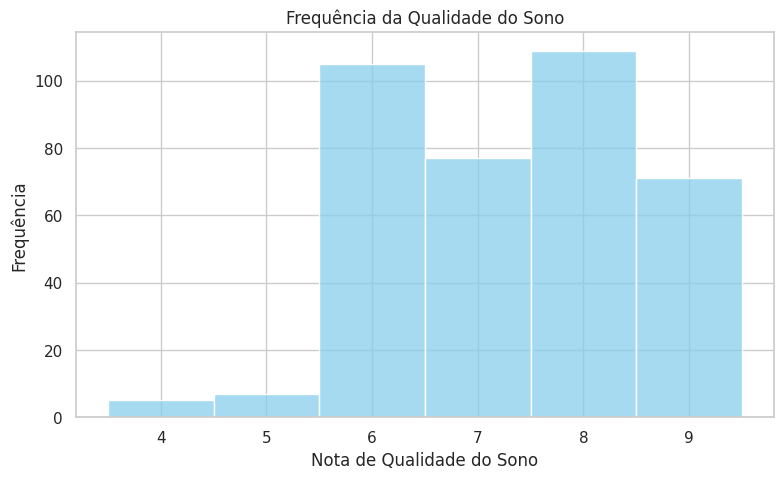

In [ ]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='Quality of Sleep', discrete=True, color='skyblue')
plt.title('Frequência da Qualidade do Sono')
plt.xlabel('Nota de Qualidade do Sono')
plt.ylabel('Frequência',)

Text(0, 0.5, 'Nota de Qualidade do Sono')

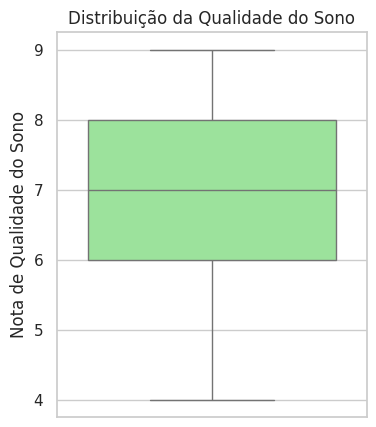

In [ ]:
plt.figure(figsize=(4, 5))
sns.boxplot(data=df, y='Quality of Sleep', color='lightgreen')
plt.title('Distribuição da Qualidade do Sono')
plt.ylabel('Nota de Qualidade do Sono')

**Análise da Distribuição da Qualidade de Sono:**

Com o boxplot, é possível analisar a distribuição da variável alvo, temos como valor mínimo e máximo, 4 e 9, respectivamente
Além disso, com a caixa principal no meio, em verde, temos 50% das observações, entre nota 6 e 8

### Qualidade do Sono x Gênero

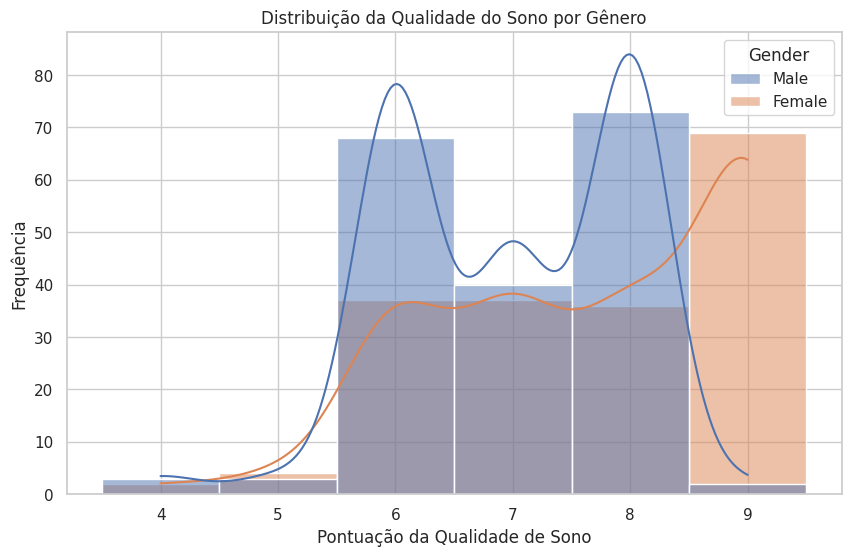

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Quality of Sleep', hue='Gender',discrete=True, kde=True, multiple="layer")
plt.title(f'Distribuição da Qualidade do Sono por Gênero')
plt.xlabel('Pontuação da Qualidade de Sono')
plt.ylabel('Frequência')
plt.show()

**Análise da Distribuição da Qualidade de Sono por Gênero:**

Com o histograma comparando a nota de sono de cada gênero, podemos ver que as pessoas do gênero feminino tem uma frequência maior de notas altas,  sendo que praticamente todas as notas 9 são de mulheres, o que mostra certa dependência entre as variáveis

### Qualidade do Sono x Idade



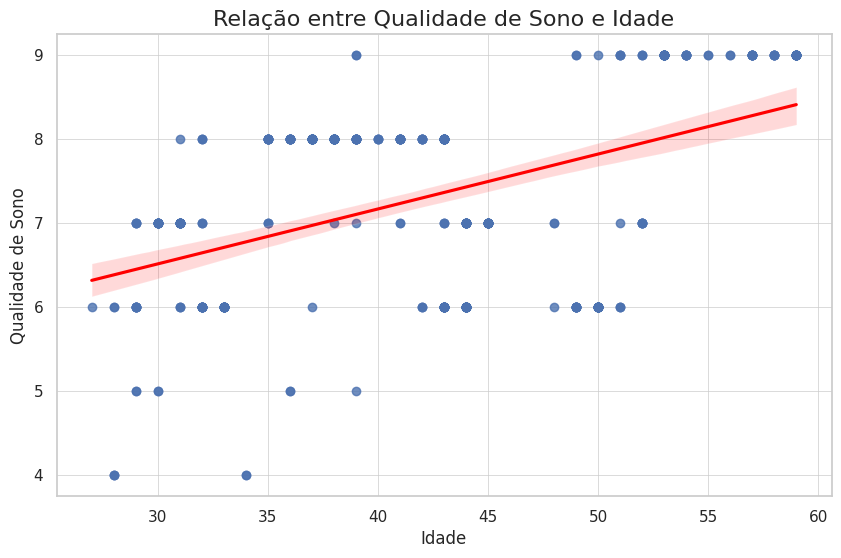

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Age', y='Quality of Sleep', line_kws={"color": "red"})
plt.title('Relação entre Qualidade de Sono e Idade', fontsize=16)
plt.xlabel('Idade', fontsize=12)
plt.ylabel('Qualidade de Sono', fontsize=12)
plt.grid(True, which='both', linestyle='-', linewidth=0.5)
plt.show()

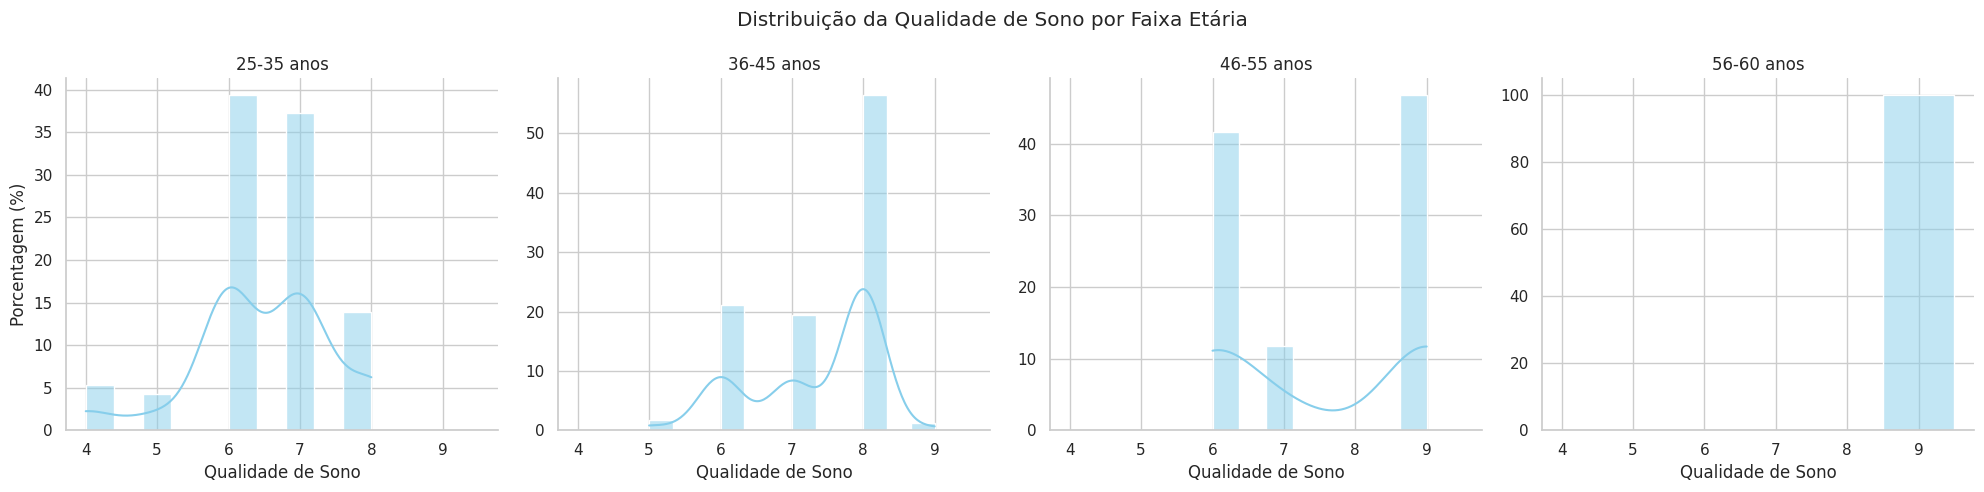

In [ ]:
df['Age Group'] = pd.cut(df['Age'], bins=[25, 35, 45, 55, 60], labels=['25-35 anos', '36-45 anos', '46-55 anos', '56-60 anos'])

g = sns.FacetGrid(df, col='Age Group', height=5, sharey=False)
g.map(sns.histplot, 'Quality of Sleep', kde=True, stat='percent', common_norm=False, color='skyblue')
g.fig.suptitle('Distribuição da Qualidade de Sono por Faixa Etária')
g.set_axis_labels("Qualidade de Sono", "Porcentagem (%)")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

**Análise da Distribuição da Qualidade de Sono por Faixa Etária:**

Analisando os gráficos, vemos que as notas mais baixas (4 e 5) e médias (6 e 7) estão majoritariamente em faixas etárias menores, no caso 25-35 anos principalmente, com uma presença de, aproximadamente, 65% dessas notas nessa faixa etária

### Qualidade do Sono x Duração do Sono

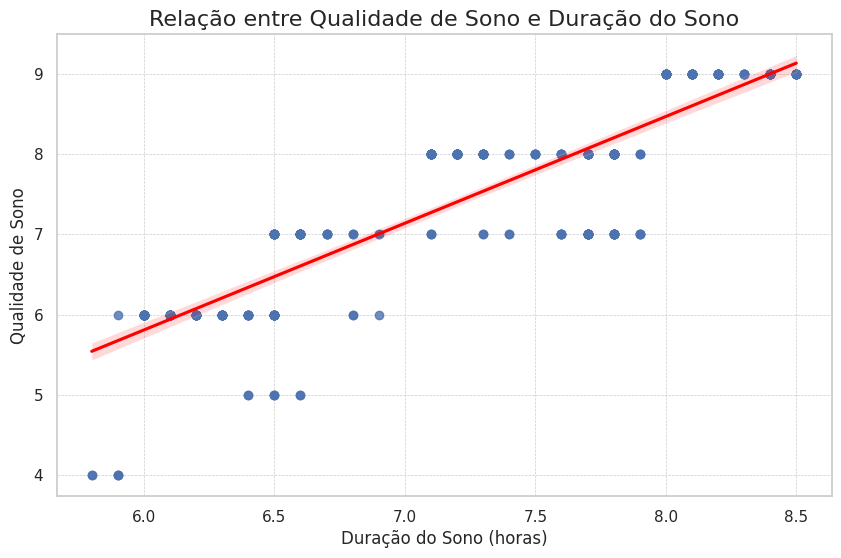

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Sleep Duration', y='Quality of Sleep', line_kws={"color": "red"})
plt.title('Relação entre Qualidade de Sono e Duração do Sono', fontsize=16)
plt.xlabel('Duração do Sono (horas)', fontsize=12)
plt.ylabel('Qualidade de Sono', fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

**Análise da Relação entre Qualidade de Sono e Duração do Sono:**

Analisando o gráfico de dispersão, observa-se que a tendência dos pontos é aumentarem no eixo y, "Qualidade de Sono", conforme aumenta o eixo x, "Duração do Sono (horas)", o que pode ser observado pela linha vermelha inclinada, indicando uma relação entre as variáveis

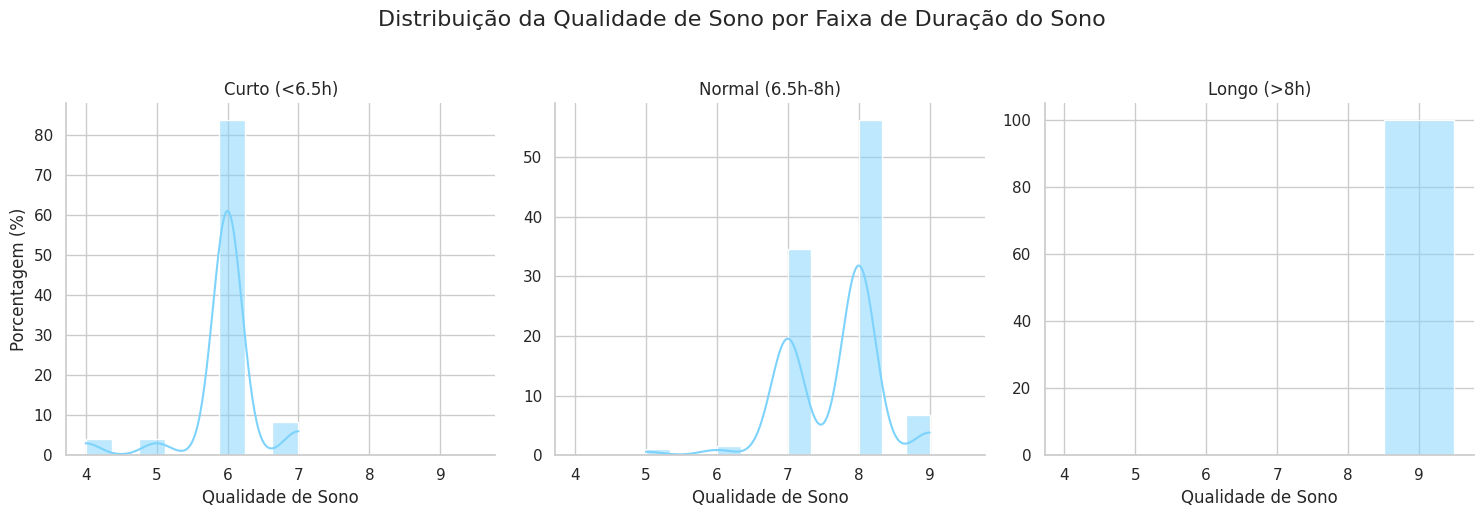

In [ ]:
min_sleep = df['Sleep Duration'].min()
max_sleep = df['Sleep Duration'].max()
df['Sleep Duration Group'] = pd.cut(df['Sleep Duration'], bins=[min_sleep-0.1, 6.5, 8.0, max_sleep+0.1], labels=['Curto (<6.5h)', 'Normal (6.5h-8h)', 'Longo (>8h)'])

g = sns.FacetGrid(df, col='Sleep Duration Group', height=5, sharey=False)
g.map(sns.histplot, 'Quality of Sleep', kde=True, stat='percent', common_norm=False, color='#7DD3FC')
g.fig.suptitle('Distribuição da Qualidade de Sono por Faixa de Duração do Sono', y=1.03, fontsize=16)
g.set_axis_labels("Qualidade de Sono", "Porcentagem (%)")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

**Análise da Distribuição da Qualidade de Sono por Faixa de Duração do Sono:**

O cenário visto no gráfico de disperção pode ser visto também dividindo em gráficos por faixa de duração de sono, comprovando o que foi vizualizado no gráfico de disperção, com notas mais altas, nas faixas de duração de sono mais altas.

### Qualidade do Sono x Categoria no IMC

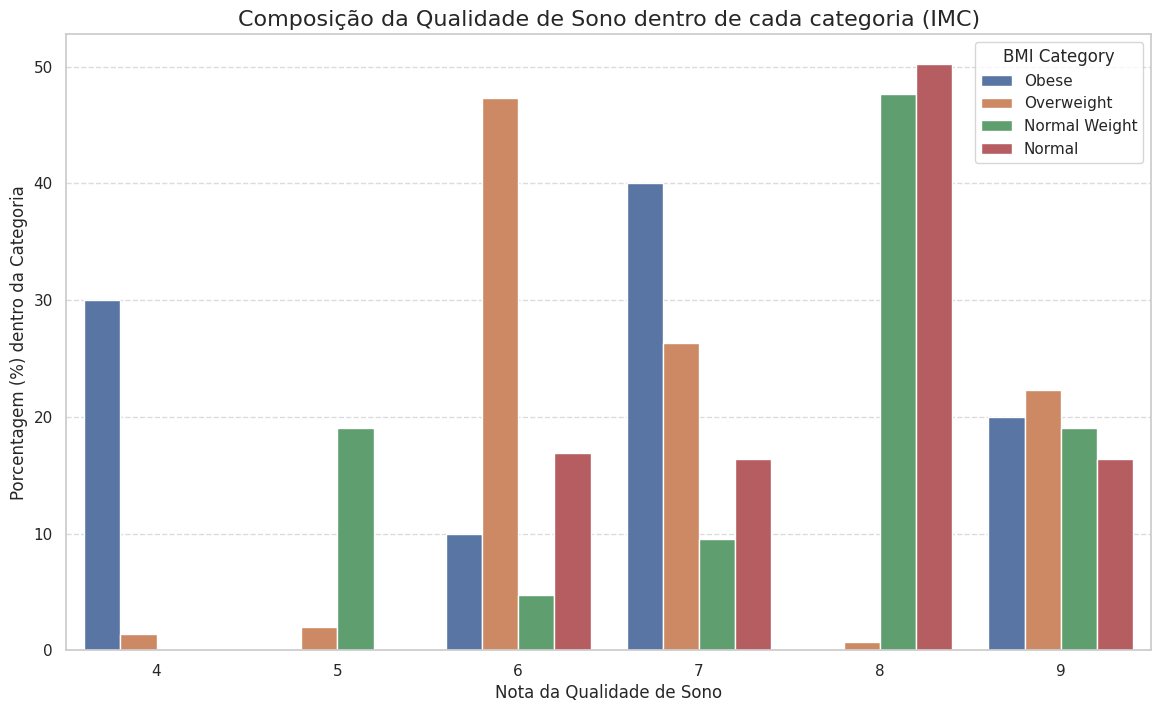

In [ ]:
percentage_df = df.groupby('BMI Category')['Quality of Sleep'].value_counts(normalize=True).mul(100).rename('Porcentagem').reset_index()
plt.figure(figsize=(14, 8))
sns.barplot(data=percentage_df,x='Quality of Sleep',y='Porcentagem',hue='BMI Category')
plt.title(f'Composição da Qualidade de Sono dentro de cada categoria (IMC)', fontsize=16)
plt.xlabel('Nota da Qualidade de Sono', fontsize=12)
plt.ylabel('Porcentagem (%) dentro da Categoria', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='BMI Category')
plt.show()


**Análise da Composição da Qualidade de Sono dentro de cada categoria de IMC:**

Com base no gráfico, é possível perceber que as pessoas obesas e com sobrepeso são as únicas que apresentam uma qualidade do sono inferior à 5, o que tende a indicar que o excesso de peso pode estar relacionado à distúrbios do sono.

Além disso, pessoas na classe de peso considerada normal estão majoritariamente (mais de 50%) em uma faixa de qualidade de sono entre 8 e 9.

### Qualidade do Sono x Faixa de Estresse

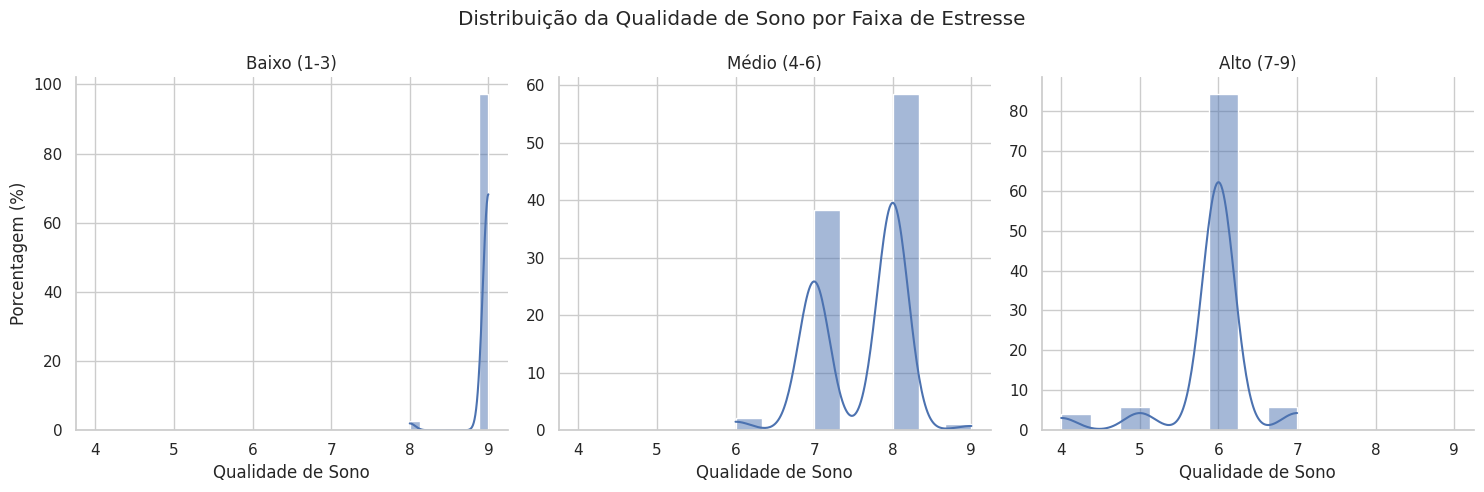

In [ ]:
df['Stress Group'] = pd.cut(df['Stress Level'], bins=[0, 3, 6, 9], labels=['Baixo (1-3)', 'Médio (4-6)', 'Alto (7-9)'])
g = sns.FacetGrid(df, col='Stress Group', height=5, sharey=False)
g.map(sns.histplot, 'Quality of Sleep', kde=True, stat='percent', common_norm=False)
g.fig.suptitle('Distribuição da Qualidade de Sono por Faixa de Estresse')
g.set_axis_labels("Qualidade de Sono", "Porcentagem (%)")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

**Análise da Distribuição da Qualidade de Sono por Faixa de Estresse:**

O nível de estresse também se mostra como um indicador relevante para a qualidade do sono :

- Pessoas com um baixo nível de estresse em sua grande maioria apresentam as notas mais altas na qualidade do sono (>90% com nota 9)
- Pessoas com um nível alto de estresse apresentam uma qualdade do sono inferior à 7

Dessa forma, há fortes indícios de dependência entre as variáveis

### Qualidade do Sono x Distúrbios

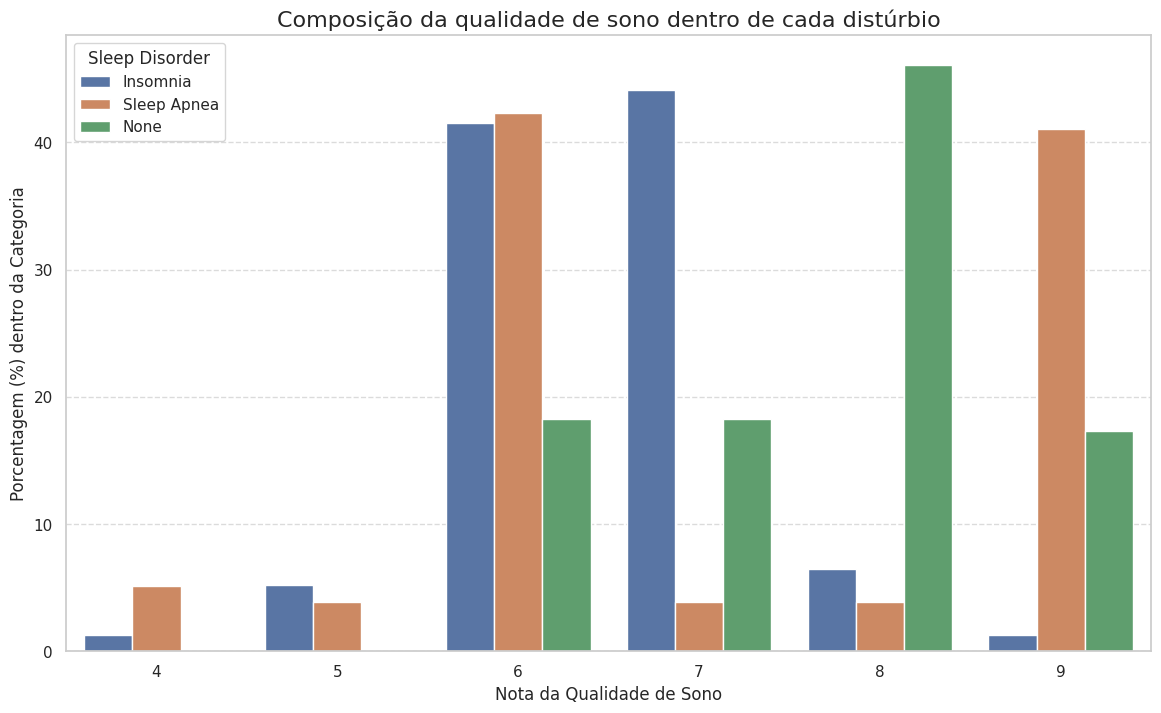

In [ ]:
sleep_percentage_df = df.groupby('Sleep Disorder')['Quality of Sleep'].value_counts(normalize=True).mul(100).rename('Porcentagens').reset_index()
plt.figure(figsize=(14, 8))
sns.barplot(data=sleep_percentage_df,x='Quality of Sleep',y='Porcentagens',hue='Sleep Disorder')
plt.title(f'Composição da qualidade de sono dentro de cada distúrbio', fontsize=16)
plt.xlabel('Nota da Qualidade de Sono', fontsize=12)
plt.ylabel('Porcentagem (%) dentro da Categoria', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Sleep Disorder')
plt.show()

**Análise da comparação entre qualidade do sono e distúrbios do sono:**

- Pessoas com os distúrbios registrados foram as únicas que apresentaram um nível menor que 6 na qualidade do sono
- A grande maioria das pessoas com insônia tem uma qualidade do sono inferior à 7
- Mesmo com apnéia do sono, uma parcela relevante dessas pessoas tem uma qualidade alta no sono (mais de 40& registrou nota 9 de qualidade)

### Qualidade do Sono x Nível de Atividade Física

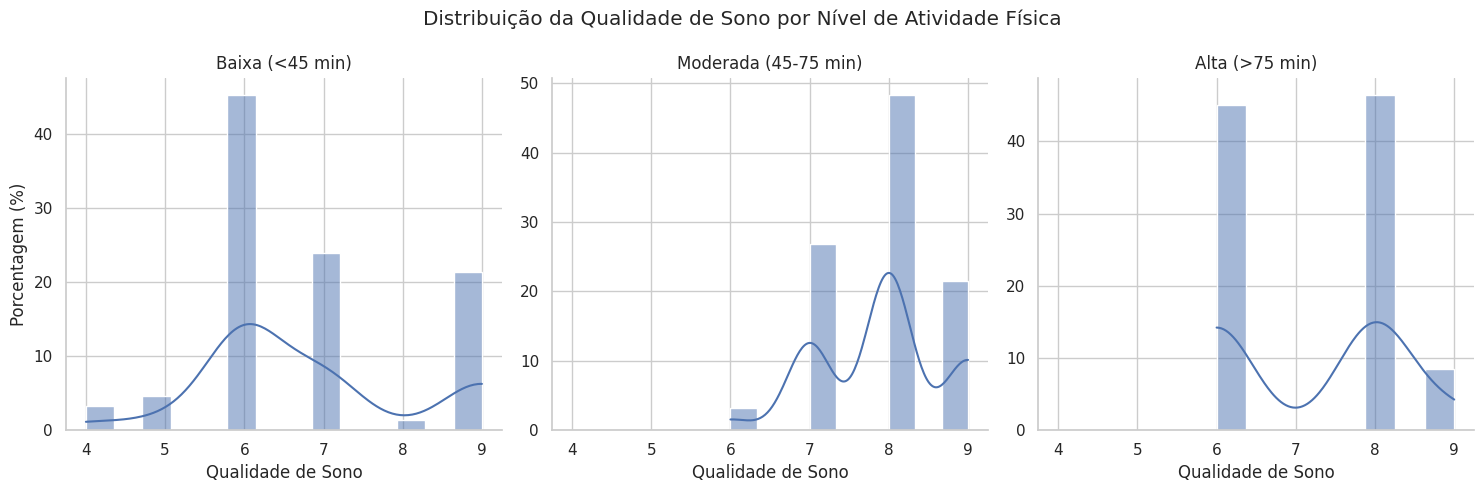

In [ ]:
df['Activity Group'] = pd.cut(df['Physical Activity Level'], bins=[0, 45, 75, df['Physical Activity Level'].max()+1], labels=['Baixa (<45 min)', 'Moderada (45-75 min)', 'Alta (>75 min)'])

g = sns.FacetGrid(df, col='Activity Group', height=5, sharey=False)
g.map(sns.histplot, 'Quality of Sleep', kde=True, stat='percent', common_norm=False)
g.fig.suptitle('Distribuição da Qualidade de Sono por Nível de Atividade Física')
g.set_axis_labels("Qualidade de Sono", "Porcentagem (%)")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

**Análise da Distribuição da Qualidade de Sono por Nível de Atividade Física:**

- Pessoas com um nível de atividade físico baixo são as únicas que apresentam uma qualidade do sono inferior à 6
- Pessoas com um nível de atividade física moderada são as que apresentam os melhores níveis de qualidade do sono
- Pessoas com um nível de atividade física alta tem uma qualidade do sono que fica majoritariamente entre 6 e 8, que acaba sendo inferior à moderada

### Qualidade do Sono x Passos no dia

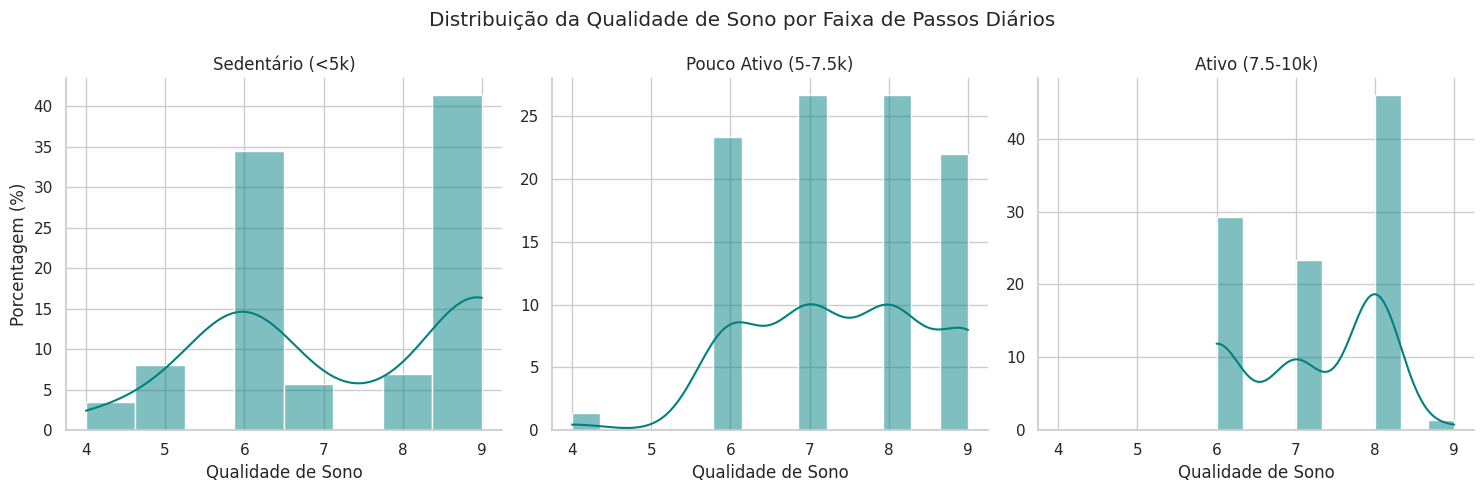

In [ ]:
df['Steps Group'] = pd.cut(df['Daily Steps'], bins=[0, 5000, 7500, 10000], labels=['Sedentário (<5k)', 'Pouco Ativo (5-7.5k)', 'Ativo (7.5-10k)'])

g = sns.FacetGrid(df, col='Steps Group', height=5, sharey=False)
g.map(sns.histplot, 'Quality of Sleep', kde=True, stat='percent', common_norm=False, color='teal')
g.fig.suptitle('Distribuição da Qualidade de Sono por Faixa de Passos Diários')
g.set_axis_labels("Qualidade de Sono", "Porcentagem (%)")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

# g = sns.FacetGrid(df, col='Activity Group', height=5, sharey=False)
# g.map(sns.histplot, 'Quality of Sleep', kde=True, stat='percent', common_norm=False)
# g.fig.suptitle('Distribuição da Qualidade de Sono por Nível de Atividade Física')
# g.set_axis_labels("Qualidade de Sono", "Porcentagem (%)")
# g.set_titles("{col_name}")
# plt.tight_layout()
# plt.show()

**Análise da Distribuição da Qualidade de Sono por Faixa de Passos Diários:**

- As pessoas mais sedentárias compôem a principal parte daquelas que possuem uma qualidade do sono inferior à 6. No entanto, apresentam uma parcela relevante com qualidade do sono próxima a nove (>40%)
- As pessoas pouco ativas tem sua faixa de qualidade principalmente entre 6 e 9
- As pessoas ativas apresentam sua maioria entre 6 e 8, sendo que são a única faixa que não apresenta nenhum registro inferior à 6

Dessa forma, percebe-se que uma quantidade de passos alta pode evitar uma qualidade do sono baixa, mas não podemos afirmar com certeza que ela irá garantir uma qualidade máxima

### Qualidade do Sono x Frequência Cardíaca

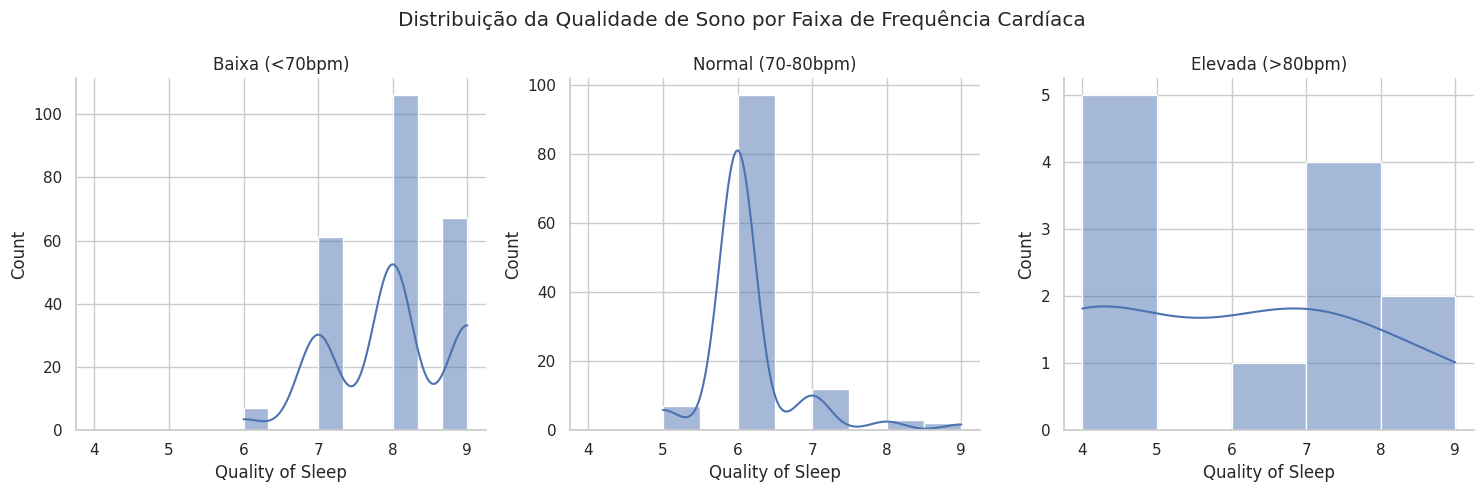

In [ ]:
df['Heart Rate Group'] = pd.cut(df['Heart Rate'], bins=[0, 70, 80, df['Heart Rate'].max()+1], labels=['Baixa (<70bpm)', 'Normal (70-80bpm)', 'Elevada (>80bpm)'])

g = sns.FacetGrid(df, col='Heart Rate Group', height=5, sharey=False)
g.map(sns.histplot, 'Quality of Sleep', kde=True)
g.fig.suptitle('Distribuição da Qualidade de Sono por Faixa de Frequência Cardíaca')
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

**Análise da Distribuição da Qualidade de Sono por Faixa de Frequência Cardíaca:**

- Pessoas cuja frequência cardíaca medida é baixa, que pode estar relacionada com um nível maior de relaxamento (baixo estresse), apresentaram  os melhores indicadores
- Pessoas cuja frequência cardíaca medida é média, apresentam um valor de qualidade do sono muito próximo de 6
- Pessoas cuja frequência cardíaca medida é elevada, que pode estar relacionada com um nível maior de estresse, apresentam uma parcela relevante com uma qualidade de sono baixa, entre 4 e 5, apesar de sua maioria estar entre 7 e 9.

# Conclusão

- Pessoas do gênero feminino tendem a ter notas de qualidade do sono mais altas.
- A idade também influencia, com faixas etárias mais jovens apresentando notas mais baixas.
- A duração do sono tem uma relação positiva com a qualidade
- Pessoas com IMC normal e níveis de estresse baixos geralmente têm melhor qualidade de sono.
- Distúrbios do sono, como insônia e apneia, impactam negativamente a qualidade do sono, embora a apneia do sono ainda possa apresentar casos de alta qualidade.
- Curiosamente, níveis moderados de atividade física parecem estar associados a melhor qualidade do sono do que níveis altos.
- A frequência cardíaca baixa também se relaciona com uma melhor qualidade de sono, o que dá base para o que verifcamos com a relação do sono com o estresse.


**Indicadores com mais dependência :** Horas de sono e nível de estresse


No entanto, também é importante ressaltar que as pessoas que apresentaram as notas mais baixas, 4 e 5, possuem algum distúrbio do sono